# 03 — PyCAP Input Inventory

**Purpose:** Build a clean inventory of the Little Plover River PyCAP inputs before changing any parameters.

This notebook is a learning and documentation notebook. It does **not** perturb anything yet.

The goal is to answer:

1. What is inside `LPR_Redux.yml`?
2. Which inputs are global project properties?
3. Which inputs are well-specific?
4. Where are likely uncertainty drivers such as `T`, `S`, `Q`, stream-related inputs, and solution settings?
5. What baseline output tables are available?
6. Which wells have the highest baseline depletion potential?

## Why this notebook matters

Before we run uncertainty experiments like:

```text
T × 0.90
T × 1.10
S × 0.90
S × 1.10
Q × 0.90
Q × 1.10
```

we need to clearly understand where those quantities live in the PyCAP configuration and outputs.


## 1. Imports and project-root setup

In [1]:
from pathlib import Path
import os
import sys
import json
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

def find_project_root(start=None):
    """Find the repository root by looking for common project marker files."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / ".git").exists() and (candidate / "environment.yml").exists():
            return candidate

    for candidate in candidates:
        if (candidate / "models").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Try opening Jupyter from the Modeling-Uncertainties repo root."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd()}")
print(f"Python executable: {sys.executable}")


Project root: /workspaces/Modeling-Uncertainties
Current working directory: /workspaces/Modeling-Uncertainties
Python executable: /opt/conda/envs/gw_uncertainty/bin/python


## 2. Define project paths

This notebook reads the copied raw PyCAP model and writes inventory tables to a results folder.


In [2]:
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
PYCAP_RESULTS_DIR = RESULTS_DIR / "pycap_runs"

LPR_PYCAP_RAW_DIR = DATA_DIR / "raw" / "lpr_pycap"
LPR_PYCAP_BASE_DIR = LPR_PYCAP_RAW_DIR / "pycap_base"
LPR_PYCAP_INPUTS_DIR = LPR_PYCAP_RAW_DIR / "inputs"
LPR_PYCAP_BASE_OUTPUT_DIR = LPR_PYCAP_BASE_DIR / "output"

INVENTORY_DIR = PYCAP_RESULTS_DIR / "input_inventory"
INVENTORY_DIR.mkdir(parents=True, exist_ok=True)

PYCAP_RUN_NAME = "LPR_Redux"
PYCAP_YAML_PATH = LPR_PYCAP_BASE_DIR / f"{PYCAP_RUN_NAME}.yml"
DEPLETION_JSON_PATH = LPR_PYCAP_BASE_DIR / "depletion_potential.json"

print(f"PyCAP YAML:          {PYCAP_YAML_PATH.relative_to(PROJECT_ROOT)}")
print(f"PyCAP inputs folder: {LPR_PYCAP_INPUTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"PyCAP output folder: {LPR_PYCAP_BASE_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Inventory folder:    {INVENTORY_DIR.relative_to(PROJECT_ROOT)}")


PyCAP YAML:          data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
PyCAP inputs folder: data/raw/lpr_pycap/inputs
PyCAP output folder: data/raw/lpr_pycap/pycap_base/output
Inventory folder:    results/pycap_runs/input_inventory


## 3. Confirm required source files exist

In [3]:
required_paths = {
    "PyCAP YAML": PYCAP_YAML_PATH,
    "Depletion-potential JSON": DEPLETION_JSON_PATH,
    "Main table report": LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.csv",
    "All time-series report": LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
    "Base stream depletion report": LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
    "LPR_Prepped.xlsx": LPR_PYCAP_INPUTS_DIR / "LPR_Prepped.xlsx",
    "LPR_Prepped_IDW.xlsx": LPR_PYCAP_INPUTS_DIR / "LPR_Prepped_IDW.xlsx",
}

path_check = pd.DataFrame(
    [
        {
            "item": name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_MB": round(path.stat().st_size / 1_000_000, 3) if path.exists() else None,
        }
        for name, path in required_paths.items()
    ]
)

path_check


,item,relative_path,exists,size_MB
0,PyCAP YAML,data/raw/lpr_pycap/pycap_base/LPR_Redux.yml,True,0.108
1,Depletion-potential JSON,data/raw/lpr_pycap/pycap_base/depletion_potent...,True,0.093
2,Main table report,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,True,0.141
3,All time-series report,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,True,13.149
4,Base stream depletion report,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,True,0.009
5,LPR_Prepped.xlsx,data/raw/lpr_pycap/inputs/LPR_Prepped.xlsx,True,0.053
6,LPR_Prepped_IDW.xlsx,data/raw/lpr_pycap/inputs/LPR_Prepped_IDW.xlsx,True,0.051


In [4]:
missing = path_check.loc[~path_check["exists"], "relative_path"].tolist()

if missing:
    raise FileNotFoundError(f"Missing required files: {missing}")

print("All required PyCAP inventory source files were found.")


All required PyCAP inventory source files were found.


## 4. Load the PyCAP YAML

This is the main configuration file for the analytical model.


In [5]:
with open(PYCAP_YAML_PATH, "r") as f:
    pycap_config = yaml.safe_load(f)

if not isinstance(pycap_config, dict):
    raise TypeError(f"Expected YAML to load as a dictionary, got {type(pycap_config)}")

print(f"Loaded YAML successfully.")
print(f"Number of top-level keys: {len(pycap_config)}")


Loaded YAML successfully.
Number of top-level keys: 656


## 5. Top-level YAML inventory

This table shows the top-level YAML keys and the Python object type stored under each key.


In [6]:
top_level_rows = []

for key, value in pycap_config.items():
    if isinstance(value, dict):
        length = len(value)
        subkeys = list(value.keys())[:12]
    elif isinstance(value, list):
        length = len(value)
        subkeys = ""
    else:
        length = np.nan
        subkeys = ""

    top_level_rows.append(
        {
            "top_level_key": key,
            "value_type": type(value).__name__,
            "length_if_collection": length,
            "first_subkeys": subkeys,
        }
    )

top_level_inventory = pd.DataFrame(top_level_rows)

top_level_inventory_path = INVENTORY_DIR / "top_level_yaml_inventory.csv"
top_level_inventory.to_csv(top_level_inventory_path, index=False)

print(f"Saved: {top_level_inventory_path.relative_to(PROJECT_ROOT)}")
top_level_inventory.head(25)


Saved: results/pycap_runs/input_inventory/top_level_yaml_inventory.csv


,top_level_key,value_type,length_if_collection,first_subkeys
0,project_properties,dict,12,"[name, T, Max_T, Min_T, S, Max_S, Min_S, Max_F..."
1,well_418,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."
2,well_466,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."
3,well_467,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."
4,well_490,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."
5,well_509,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."
6,well_602,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."
7,well_603,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."
8,well_798,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."
9,well_807,dict,8,"[name, status, loc, Q, pumping_days, stream_ap..."


In [7]:
top_level_type_counts = top_level_inventory["value_type"].value_counts().rename_axis("value_type").reset_index(name="count")
top_level_type_counts


,value_type,count
0,dict,656


## 6. Project properties inventory

These are global PyCAP settings. This is where important values like transmissivity `T` and storage `S` are expected.


In [8]:
project_properties = pycap_config.get("project_properties", {})

if not isinstance(project_properties, dict):
    raise TypeError("Expected project_properties to be a dictionary.")

project_properties_inventory = pd.DataFrame(
    [
        {
            "property": key,
            "value": value,
            "value_type": type(value).__name__,
        }
        for key, value in project_properties.items()
    ]
)

project_properties_path = INVENTORY_DIR / "project_properties_inventory.csv"
project_properties_inventory.to_csv(project_properties_path, index=False)

print(f"Saved: {project_properties_path.relative_to(PROJECT_ROOT)}")
project_properties_inventory


Saved: results/pycap_runs/input_inventory/project_properties_inventory.csv


,property,value,value_type
0,name,LPR_Redux,str
1,T,1700.0,float
2,Max_T,60000.0,float
3,Min_T,600.0,float
4,S,0.12,float
5,Max_S,0.2,float
6,Min_S,0.05,float
7,Max_FracInt,1.0,float
8,Min_FracInt,0.0,float
9,default_dd_days,90.0,float


## 7. Highlight likely global uncertainty parameters

This cell pulls out project-level values that are likely important for uncertainty analysis.

Common examples:

- `T` = transmissivity
- `S` = storage or storage coefficient
- depletion time horizon
- pumping duration


In [9]:
keywords_global = [
    "T",
    "transmissivity",
    "S",
    "storage",
    "depletion",
    "pump",
    "pumping",
    "day",
    "year",
    "stream",
    "solution",
]

global_uncertainty_candidates = project_properties_inventory[
    project_properties_inventory["property"].astype(str).str.lower().apply(
        lambda text: any(keyword.lower() in text for keyword in keywords_global)
    )
].copy()

global_uncertainty_candidates


,property,value,value_type
1,T,1700.0,float
2,Max_T,60000.0,float
3,Min_T,600.0,float
4,S,0.12,float
5,Max_S,0.2,float
6,Min_S,0.05,float
7,Max_FracInt,1.0,float
8,Min_FracInt,0.0,float
9,default_dd_days,90.0,float
10,default_depletion_years,5.0,float


## 8. Build a well inventory table

The PyCAP LPR YAML stores many wells as top-level entries. This cell identifies likely well entries and extracts:

- well ID
- well name
- pumping rate `Q`
- pumping rate converted from gpm to cfs
- coordinates
- available keys within each well entry

The conversion is:

$$
1\ \mathrm{gpm} = \frac{1}{7.48052 \times 60}\ \mathrm{cfs}
$$


In [10]:
GPM_TO_CFS = 1 / 7.48052 / 60

def is_likely_well_entry(key, value):
    """Identify likely well entries from the PyCAP YAML."""
    if not isinstance(value, dict):
        return False

    key_text = str(key).lower()
    has_q = "Q" in value or "q" in value
    has_loc = isinstance(value.get("loc"), dict)
    key_says_well = "well" in key_text

    return key_says_well and (has_q or has_loc)

well_rows = []

for key, value in pycap_config.items():
    if not is_likely_well_entry(key, value):
        continue

    loc = value.get("loc", {})
    q_gpm = value.get("Q", value.get("q", np.nan))
    q_cfs = q_gpm * GPM_TO_CFS if pd.notna(q_gpm) else np.nan

    well_rows.append(
        {
            "well_key": key,
            "name": value.get("name", key),
            "Q_gpm": q_gpm,
            "Q_cfs": q_cfs,
            "x": loc.get("x", np.nan) if isinstance(loc, dict) else np.nan,
            "y": loc.get("y", np.nan) if isinstance(loc, dict) else np.nan,
            "number_of_fields": len(value),
            "available_fields": sorted(list(value.keys())),
        }
    )

wells_df = pd.DataFrame(well_rows)

well_inventory_path = INVENTORY_DIR / "well_inventory.csv"
wells_df.to_csv(well_inventory_path, index=False)

print(f"Number of likely well entries: {len(wells_df)}")
print(f"Saved: {well_inventory_path.relative_to(PROJECT_ROOT)}")

wells_df.head(10)


Number of likely well entries: 327
Saved: results/pycap_runs/input_inventory/well_inventory.csv


,well_key,name,Q_gpm,Q_cfs,x,y,number_of_fields,available_fields
0,well_418,418,109.5,0.243967,89.483927,44.443073,8,"[Q, dd_response, loc, name, pumping_days, stat..."
1,well_466,466,315.9,0.703828,89.493950,44.461175,8,"[Q, dd_response, loc, name, pumping_days, stat..."
2,well_467,467,296.9,0.661496,89.493973,44.458573,8,"[Q, dd_response, loc, name, pumping_days, stat..."
3,well_490,490,27.7,0.061716,89.312108,44.466657,8,"[Q, dd_response, loc, name, pumping_days, stat..."
4,well_509,509,0.1,0.000223,89.471377,44.520602,8,"[Q, dd_response, loc, name, pumping_days, stat..."
5,well_602,602,0.5,0.001114,89.302578,44.454248,8,"[Q, dd_response, loc, name, pumping_days, stat..."
6,well_603,603,0.2,0.000446,89.303522,44.454840,8,"[Q, dd_response, loc, name, pumping_days, stat..."
7,well_798,798,135.6,0.302118,89.402438,44.396550,8,"[Q, dd_response, loc, name, pumping_days, stat..."
8,well_807,807,82.6,0.184034,89.482813,44.423235,8,"[Q, dd_response, loc, name, pumping_days, stat..."
9,well_850,850,107.2,0.238843,89.491648,44.539970,8,"[Q, dd_response, loc, name, pumping_days, stat..."


In [11]:
wells_df[["Q_gpm", "Q_cfs", "x", "y", "number_of_fields"]].describe()


,Q_gpm,Q_cfs,x,y,number_of_fields
count,327.000000,327.000000,327.000000,327.000000,327.0
mean,159.857187,0.356163,89.450443,44.472320,8.0
std,147.298725,0.328183,0.063534,0.051243,0.0
min,0.100000,0.000223,89.287740,44.382800,8.0
25%,42.950000,0.095693,89.422466,44.431238,8.0
50%,132.900000,0.296102,89.456558,44.463364,8.0
75%,244.150000,0.543968,89.495926,44.504048,8.0
max,1133.700000,2.525894,89.574306,44.595528,8.0


## 9. Well-field frequency table

This shows which fields appear inside well entries.

Fields that appear in many or all well entries are good candidates for structured uncertainty or sensitivity analysis.


In [12]:
field_counter = Counter()

for fields in wells_df["available_fields"]:
    for field in fields:
        field_counter[field] += 1

well_field_frequency = pd.DataFrame(
    [
        {"field": field, "count": count, "fraction_of_wells": count / len(wells_df)}
        for field, count in field_counter.items()
    ]
).sort_values(["count", "field"], ascending=[False, True])

well_field_frequency_path = INVENTORY_DIR / "well_field_frequency.csv"
well_field_frequency.to_csv(well_field_frequency_path, index=False)

print(f"Saved: {well_field_frequency_path.relative_to(PROJECT_ROOT)}")
well_field_frequency


Saved: results/pycap_runs/input_inventory/well_field_frequency.csv


,field,count,fraction_of_wells
0,Q,327,1.000000
1,dd_response,327,1.000000
2,loc,327,1.000000
3,name,327,1.000000
4,pumping_days,327,1.000000
...,...,...,...
102,stream_apportionment95,1,0.003058
103,stream_apportionment96,1,0.003058
104,stream_apportionment97,1,0.003058
105,stream_apportionment98,1,0.003058


## 10. Search the full YAML for uncertainty-related keys

This recursively scans the YAML for terms related to uncertainty.

This is useful because not every important PyCAP input is necessarily stored in `project_properties` or inside well entries.


In [13]:
def flatten_yaml(obj, prefix=""):
    """Flatten nested dictionaries/lists into path-value records."""
    records = []

    if isinstance(obj, dict):
        for key, value in obj.items():
            path = f"{prefix}.{key}" if prefix else str(key)
            records.extend(flatten_yaml(value, path))
    elif isinstance(obj, list):
        for i, value in enumerate(obj):
            path = f"{prefix}[{i}]"
            records.extend(flatten_yaml(value, path))
    else:
        records.append(
            {
                "path": prefix,
                "leaf_key": prefix.split(".")[-1] if prefix else "",
                "value": obj,
                "value_type": type(obj).__name__,
            }
        )

    return records

flat_yaml = pd.DataFrame(flatten_yaml(pycap_config))

flat_yaml_path = INVENTORY_DIR / "flat_yaml_inventory.csv"
flat_yaml.to_csv(flat_yaml_path, index=False)

print(f"Flattened YAML leaf values: {len(flat_yaml)}")
print(f"Saved: {flat_yaml_path.relative_to(PROJECT_ROOT)}")
flat_yaml.head()


Flattened YAML leaf values: 3940
Saved: results/pycap_runs/input_inventory/flat_yaml_inventory.csv


,path,leaf_key,value,value_type
0,project_properties.name,name,LPR_Redux,str
1,project_properties.T,T,1700.0,float
2,project_properties.Max_T,Max_T,60000.0,float
3,project_properties.Min_T,Min_T,600.0,float
4,project_properties.S,S,0.12,float


In [14]:
uncertainty_terms = [
    "transmissivity",
    ".T",
    "storage",
    ".S",
    "conductance",
    "streambed",
    "leakance",
    "resistance",
    "pump",
    "pumping",
    ".Q",
    "depletion",
    "apportion",
    "fraction",
    "distance",
    "stream",
    "solution",
    "theis",
    "hunt",
    "glover",
    "loc",
    "x",
    "y",
]

def path_matches_terms(path, terms):
    path_lower = str(path).lower()
    return any(term.lower().strip(".") in path_lower for term in terms)

uncertainty_key_inventory = flat_yaml[
    flat_yaml["path"].apply(lambda p: path_matches_terms(p, uncertainty_terms))
].copy()

uncertainty_key_inventory_path = INVENTORY_DIR / "uncertainty_key_inventory.csv"
uncertainty_key_inventory.to_csv(uncertainty_key_inventory_path, index=False)

print(f"Potential uncertainty-related YAML leaf values: {len(uncertainty_key_inventory)}")
print(f"Saved: {uncertainty_key_inventory_path.relative_to(PROJECT_ROOT)}")

uncertainty_key_inventory.head(50)


Potential uncertainty-related YAML leaf values: 3613
Saved: results/pycap_runs/input_inventory/uncertainty_key_inventory.csv


,path,leaf_key,value,value_type
0,project_properties.name,name,LPR_Redux,str
1,project_properties.T,T,1700.0,float
2,project_properties.Max_T,Max_T,60000.0,float
3,project_properties.Min_T,Min_T,600.0,float
4,project_properties.S,S,0.12,float
5,project_properties.Max_S,Max_S,0.2,float
6,project_properties.Min_S,Min_S,0.05,float
7,project_properties.Max_FracInt,Max_FracInt,1.0,float
8,project_properties.Min_FracInt,Min_FracInt,0.0,float
9,project_properties.default_dd_days,default_dd_days,90.0,float


## 11. Search specifically for solution or method settings

This helps identify whether the analytical solution form is explicitly stored in the YAML.

If very little appears here, solution choice may be controlled internally by PyCAP or by a higher-level project setting.


In [15]:
solution_terms = ["solution", "theis", "hunt", "glover", "jenkins", "method", "model"]

solution_inventory = flat_yaml[
    flat_yaml["path"].astype(str).str.lower().apply(
        lambda path: any(term in path for term in solution_terms)
    )
].copy()

solution_inventory_path = INVENTORY_DIR / "solution_method_inventory.csv"
solution_inventory.to_csv(solution_inventory_path, index=False)

print(f"Solution/method-related records: {len(solution_inventory)}")
print(f"Saved: {solution_inventory_path.relative_to(PROJECT_ROOT)}")
solution_inventory.head(50)


Solution/method-related records: 0
Saved: results/pycap_runs/input_inventory/solution_method_inventory.csv


,path,leaf_key,value,value_type


## 12. Search specifically for stream-related entries

This cell looks for top-level and nested YAML entries containing the word `stream`.

This may help locate stream response settings, stream names, stream segments, or stream-depletion targets.


In [16]:
stream_top_level = top_level_inventory[
    top_level_inventory["top_level_key"].astype(str).str.lower().str.contains("stream")
].copy()

stream_nested = flat_yaml[
    flat_yaml["path"].astype(str).str.lower().str.contains("stream")
].copy()

stream_top_level_path = INVENTORY_DIR / "stream_top_level_inventory.csv"
stream_nested_path = INVENTORY_DIR / "stream_nested_inventory.csv"

stream_top_level.to_csv(stream_top_level_path, index=False)
stream_nested.to_csv(stream_nested_path, index=False)

print(f"Top-level stream-like entries: {len(stream_top_level)}")
print(f"Nested stream-like leaf values: {len(stream_nested)}")
print(f"Saved: {stream_top_level_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {stream_nested_path.relative_to(PROJECT_ROOT)}")

stream_top_level.head(25)


Top-level stream-like entries: 327
Nested stream-like leaf values: 1962
Saved: results/pycap_runs/input_inventory/stream_top_level_inventory.csv
Saved: results/pycap_runs/input_inventory/stream_nested_inventory.csv


,top_level_key,value_type,length_if_collection,first_subkeys
329,stream_response0,dict,2,"[name, loc]"
330,stream_response1,dict,2,"[name, loc]"
331,stream_response2,dict,2,"[name, loc]"
332,stream_response3,dict,2,"[name, loc]"
333,stream_response4,dict,2,"[name, loc]"
334,stream_response5,dict,2,"[name, loc]"
335,stream_response6,dict,2,"[name, loc]"
336,stream_response7,dict,2,"[name, loc]"
337,stream_response8,dict,2,"[name, loc]"
338,stream_response9,dict,2,"[name, loc]"


In [17]:
stream_nested.head(50)


,path,leaf_key,value,value_type
18,well_418.stream_apportionment0.name,name,LPR:418,str
19,well_418.stream_apportionment0.apportionment,apportionment,0.50863,float
20,well_418.stream_response[0],stream_response[0],LPR:418,str
28,well_466.stream_apportionment1.name,name,LPR:466,str
29,well_466.stream_apportionment1.apportionment,apportionment,0.822249,float
30,well_466.stream_response[0],stream_response[0],LPR:466,str
37,well_467.stream_apportionment2.name,name,LPR:467,str
38,well_467.stream_apportionment2.apportionment,apportionment,0.768924,float
39,well_467.stream_response[0],stream_response[0],LPR:467,str
46,well_490.stream_apportionment3.name,name,LPR:490,str


## 13. Inventory copied PyCAP input workbooks and fish-curve files

These were copied from the original LPR PyCAP input folder.


In [18]:
input_files = sorted([p for p in LPR_PYCAP_INPUTS_DIR.rglob("*") if p.is_file()])

input_file_inventory = pd.DataFrame(
    [
        {
            "file": p.name,
            "relative_path": str(p.relative_to(PROJECT_ROOT)),
            "suffix": p.suffix,
            "size_MB": round(p.stat().st_size / 1_000_000, 3),
            "modified_time": datetime.fromtimestamp(p.stat().st_mtime).isoformat(timespec="seconds"),
        }
        for p in input_files
    ]
)

input_file_inventory_path = INVENTORY_DIR / "copied_input_file_inventory.csv"
input_file_inventory.to_csv(input_file_inventory_path, index=False)

print(f"Saved: {input_file_inventory_path.relative_to(PROJECT_ROOT)}")
input_file_inventory


Saved: results/pycap_runs/input_inventory/copied_input_file_inventory.csv


,file,relative_path,suffix,size_MB,modified_time
0,InitialFractionInterceptEstimator_Tool.xlsx,data/raw/lpr_pycap/inputs/InitialFractionInter...,.xlsx,0.216,2026-04-19T03:36:55
1,LPR2025.xlsx,data/raw/lpr_pycap/inputs/LPR2025.xlsx,.xlsx,3.360,2026-04-19T03:36:55
2,LPR_Init.xlsx,data/raw/lpr_pycap/inputs/LPR_Init.xlsx,.xlsx,0.101,2026-04-19T03:36:55
3,LPR_Prepped.xlsx,data/raw/lpr_pycap/inputs/LPR_Prepped.xlsx,.xlsx,0.053,2026-04-19T03:36:55
4,LPR_Prepped_IDW.xlsx,data/raw/lpr_pycap/inputs/LPR_Prepped_IDW.xlsx,.xlsx,0.051,2026-04-19T03:36:55
5,Brook.csv,data/raw/lpr_pycap/inputs/fish_curves/Brook.csv,.csv,0.013,2026-04-19T03:36:55
6,Brown.csv,data/raw/lpr_pycap/inputs/fish_curves/Brown.csv,.csv,0.014,2026-04-19T03:36:55
7,LPR_AvgFlows.xlsx,data/raw/lpr_pycap/inputs/fish_curves/LPR_AvgF...,.xlsx,0.624,2026-04-19T03:36:55
8,Rainbow.csv,data/raw/lpr_pycap/inputs/fish_curves/Rainbow.csv,.csv,0.013,2026-04-19T03:36:55
9,test_runMC.xlsx,data/raw/lpr_pycap/inputs/test_runMC.xlsx,.xlsx,0.039,2026-04-19T03:36:55


## 14. Inspect Excel workbook sheet names

This does not read all workbook data. It only inventories sheet names so we know what source tables may exist.


In [19]:
excel_files = [p for p in input_files if p.suffix.lower() in [".xlsx", ".xls"]]

excel_sheet_rows = []

for excel_path in excel_files:
    try:
        xls = pd.ExcelFile(excel_path)
        for sheet_name in xls.sheet_names:
            excel_sheet_rows.append(
                {
                    "workbook": excel_path.name,
                    "relative_path": str(excel_path.relative_to(PROJECT_ROOT)),
                    "sheet_name": sheet_name,
                }
            )
    except Exception as err:
        excel_sheet_rows.append(
            {
                "workbook": excel_path.name,
                "relative_path": str(excel_path.relative_to(PROJECT_ROOT)),
                "sheet_name": f"ERROR: {type(err).__name__}: {err}",
            }
        )

excel_sheet_inventory = pd.DataFrame(excel_sheet_rows)

excel_sheet_inventory_path = INVENTORY_DIR / "excel_sheet_inventory.csv"
excel_sheet_inventory.to_csv(excel_sheet_inventory_path, index=False)

print(f"Saved: {excel_sheet_inventory_path.relative_to(PROJECT_ROOT)}")
excel_sheet_inventory


Saved: results/pycap_runs/input_inventory/excel_sheet_inventory.csv


,workbook,relative_path,sheet_name
0,InitialFractionInterceptEstimator_Tool.xlsx,data/raw/lpr_pycap/inputs/InitialFractionInter...,Sheet1
1,LPR2025.xlsx,data/raw/lpr_pycap/inputs/LPR2025.xlsx,Summary
2,LPR2025.xlsx,data/raw/lpr_pycap/inputs/LPR2025.xlsx,Total Withdrawals by Property
3,LPR2025.xlsx,data/raw/lpr_pycap/inputs/LPR2025.xlsx,HC_155
4,LPR2025.xlsx,data/raw/lpr_pycap/inputs/LPR2025.xlsx,HC_373
...,...,...,...
705,test_runMC.xlsx,data/raw/lpr_pycap/inputs/test_runMC.xlsx,Global_Inputs
706,test_runMC.xlsx,data/raw/lpr_pycap/inputs/test_runMC.xlsx,HCW_Inputs
707,test_runMC.xlsx,data/raw/lpr_pycap/inputs/test_runMC.xlsx,Depletion_Inputs
708,test_runMC.xlsx,data/raw/lpr_pycap/inputs/test_runMC.xlsx,Drawdown_Inputs


## 15. Inventory baseline PyCAP output tables

Now we inspect the copied baseline PyCAP output tables.


In [20]:
baseline_output_paths = {
    "table_report": LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.csv",
    "all_ts": LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
    "base_stream_depletion": LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
}

output_table_rows = []
baseline_tables = {}

for table_name, path in baseline_output_paths.items():
    df = pd.read_csv(path)
    baseline_tables[table_name] = df

    output_table_rows.append(
        {
            "table": table_name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "n_rows": df.shape[0],
            "n_columns": df.shape[1],
            "columns": list(df.columns),
        }
    )

output_table_inventory = pd.DataFrame(output_table_rows)

output_table_inventory_path = INVENTORY_DIR / "baseline_output_table_inventory.csv"
output_table_inventory.to_csv(output_table_inventory_path, index=False)

print(f"Saved: {output_table_inventory_path.relative_to(PROJECT_ROOT)}")
output_table_inventory


Saved: results/pycap_runs/input_inventory/baseline_output_table_inventory.csv


,table,relative_path,n_rows,n_columns,columns
0,table_report,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,330,329,"[Unnamed: 0, LakeEmily:dd (ft), LPR:466:depl (..."
1,all_ts,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,1825,328,"[Unnamed: 0, LPR:466, LPR:467, LPR:490, LPR:50..."
2,base_stream_depletion,data/raw/lpr_pycap/pycap_base/output/LPR_Redux...,330,2,"[Unnamed: 0, LPR]"


## 16. Preview baseline output tables

In [21]:
baseline_tables["table_report"].head()


,Unnamed: 0,LakeEmily:dd (ft),LPR:466:depl (cfs),LPR:467:depl (cfs),LPR:490:depl (cfs),LPR:509:depl (cfs),LPR:602:depl (cfs),LPR:603:depl (cfs),LPR:798:depl (cfs),LPR:807:depl (cfs),...,LPR:93349:depl (cfs),LPR:93422:depl (cfs),LPR:93423:depl (cfs),LPR:93424:depl (cfs),LPR:93469:depl (cfs),LPR:93832:depl (cfs),LPR:94302:depl (cfs),LPR:94988:depl (cfs),LPR:95068:depl (cfs),LPR:418:depl (cfs)
0,418: proposed,6.294692e-138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00669
1,466: existing,NaN,0.383091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,467: existing,NaN,NaN,0.28748,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,490: existing,NaN,NaN,NaN,5.003177e-12,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,509: existing,NaN,NaN,NaN,NaN,2.753485e-07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
baseline_tables["all_ts"].head()


,Unnamed: 0,LPR:466,LPR:467,LPR:490,LPR:509,LPR:602,LPR:603,LPR:798,LPR:807,LPR:850,...,LPR:93349,LPR:93422,LPR:93423,LPR:93424,LPR:93469,LPR:93832,LPR:94302,LPR:94988,LPR:95068,LPR:418
0,1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,2,7.126705e-37,3.978481e-48,3.375552e-151,9.487660e-113,7.311351e-156,5.300119e-156,2.716525e-139,1.955539e-109,7.314850e-125,...,6.394061e-115,2.032288e-154,2.430096e-154,7.447175e-154,3.137448e-87,4.373206e-155,6.807363e-65,8.144461e-138,4.024010e-119,4.212407e-85
2,3,5.576801e-25,3.453310e-35,7.603759e-137,1.501469e-98,1.670569e-141,1.209592e-141,5.733115e-125,3.079092e-95,1.369828e-110,...,1.072784e-100,4.594694e-140,5.491872e-140,1.681557e-139,3.279575e-73,1.003002e-140,2.931206e-51,1.688229e-123,7.092587e-105,4.136022e-71
3,4,5.495254e-19,3.778721e-28,1.818374e-128,2.738904e-90,4.038443e-133,2.921450e-133,1.304803e-116,5.594504e-87,2.846016e-102,...,2.048000e-92,1.101836e-131,1.316584e-131,4.028593e-131,4.268202e-65,2.431604e-132,1.676088e-43,3.790086e-115,1.406590e-96,5.101717e-63
4,5,2.440341e-15,1.561220e-23,1.566369e-122,1.874876e-84,3.510404e-127,2.537552e-127,1.078267e-110,3.816487e-81,2.177924e-96,...,1.458072e-86,9.513441e-126,1.136471e-125,3.475549e-125,2.155603e-59,2.118730e-126,3.745985e-38,3.096300e-109,1.034632e-90,2.449865e-57


In [23]:
baseline_tables["base_stream_depletion"].head()


,Unnamed: 0,LPR
0,418,6.689931e-03
1,466,3.830911e-01
2,467,2.874797e-01
3,490,5.003177e-12
4,509,2.753485e-07


## 17. Calculate baseline depletion potential from YAML + output table

Here we calculate:

$$
DP = \frac{\text{stream depletion from a well}}{\text{well pumping rate}}
$$

For this LPR workflow:

- `DEPL_cfs` comes from the `LPR` column in `base_stream_depletion`
- `Q_cfs` comes from the YAML well pumping rate after unit conversion


In [24]:
base_stream_depletion = pd.read_csv(
    LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
    index_col=0,
)

if "LPR" not in base_stream_depletion.columns:
    raise KeyError(
        f"Expected an 'LPR' column in base_stream_depletion. Available columns: {list(base_stream_depletion.columns)}"
    )

depletion_df = base_stream_depletion[["LPR"]].rename(columns={"LPR": "DEPL_cfs"})

depletion_potential_df = wells_df.merge(
    depletion_df,
    left_on="name",
    right_index=True,
    how="left",
)

depletion_potential_df["Depletion_Potential"] = (
    depletion_potential_df["DEPL_cfs"] / depletion_potential_df["Q_cfs"]
)

depletion_potential_df = depletion_potential_df.sort_values(
    "Depletion_Potential",
    ascending=False,
)

dp_inventory_path = INVENTORY_DIR / "baseline_depletion_potential_inventory.csv"
depletion_potential_df.to_csv(dp_inventory_path, index=False)

print(f"Saved: {dp_inventory_path.relative_to(PROJECT_ROOT)}")
depletion_potential_df.head(20)


Saved: results/pycap_runs/input_inventory/baseline_depletion_potential_inventory.csv


,well_key,name,Q_gpm,Q_cfs,x,y,number_of_fields,available_fields,DEPL_cfs,Depletion_Potential
30,well_23627,23627,276.5,0.616045,89.484380,44.475732,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.345167,0.560296
222,well_68529,68529,219.9,0.489939,89.484333,44.479917,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.274004,0.559261
41,well_23653,23653,263.6,0.587303,89.498433,44.465117,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.326483,0.555901
1,well_466,466,315.9,0.703828,89.493950,44.461175,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.383091,0.544296
114,well_23934,23934,370.6,0.825700,89.477778,44.486112,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.398148,0.482195
229,well_69049,69049,37.6,0.083773,89.475600,44.484350,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.039051,0.466146
2,well_467,467,296.9,0.661496,89.493973,44.458573,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.287480,0.434590
259,well_71109,71109,15.0,0.033420,89.496006,44.485207,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.014082,0.421362
200,well_24323,24323,206.4,0.459861,89.503300,44.464950,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.162236,0.352793
260,well_71110,71110,13.0,0.028964,89.498127,44.484075,8,"[Q, dd_response, loc, name, pumping_days, stat...",0.009220,0.318309


## 18. Baseline depletion-potential summary

This tells us the current baseline distribution before any uncertainty experiments.


In [25]:
dp_values = depletion_potential_df["Depletion_Potential"].dropna()

dp_summary = dp_values.describe().to_frame(name="Depletion_Potential")
dp_summary


,Depletion_Potential
count,3.270000e+02
mean,3.215237e-02
std,9.248038e-02
min,5.126741e-14
25%,2.618120e-06
50%,3.622834e-04
75%,1.288858e-02
max,5.602955e-01


In [26]:
dp_thresholds = [0.001, 0.01, 0.05, 0.10, 0.20, 0.50]

threshold_summary = pd.DataFrame(
    [
        {
            "DP_threshold": threshold,
            "wells_at_or_above_threshold": int((dp_values >= threshold).sum()),
            "fraction_of_wells": float((dp_values >= threshold).mean()),
        }
        for threshold in dp_thresholds
    ]
)

threshold_summary_path = INVENTORY_DIR / "baseline_dp_threshold_summary.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

print(f"Saved: {threshold_summary_path.relative_to(PROJECT_ROOT)}")
threshold_summary


Saved: results/pycap_runs/input_inventory/baseline_dp_threshold_summary.csv


,DP_threshold,wells_at_or_above_threshold,fraction_of_wells
0,0.001,144,0.440367
1,0.010,86,0.262997
2,0.050,43,0.131498
3,0.100,29,0.088685
4,0.200,19,0.058104
5,0.500,4,0.012232


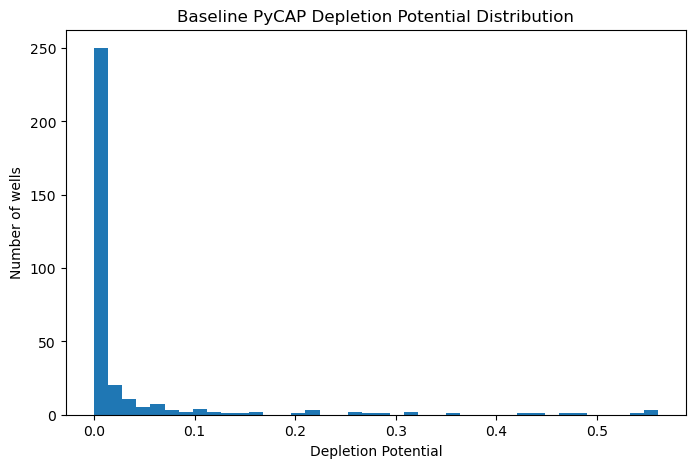

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(dp_values, bins=40)
plt.xlabel("Depletion Potential")
plt.ylabel("Number of wells")
plt.title("Baseline PyCAP Depletion Potential Distribution")
plt.show()


## 19. Identify the highest-DP wells

These wells are likely to be most decision-relevant in later uncertainty tests.


In [28]:
top_dp_wells = depletion_potential_df[
    [
        "well_key",
        "name",
        "Q_gpm",
        "Q_cfs",
        "DEPL_cfs",
        "Depletion_Potential",
        "x",
        "y",
    ]
].head(25).copy()

top_dp_wells_path = INVENTORY_DIR / "top_25_depletion_potential_wells.csv"
top_dp_wells.to_csv(top_dp_wells_path, index=False)

print(f"Saved: {top_dp_wells_path.relative_to(PROJECT_ROOT)}")
top_dp_wells


Saved: results/pycap_runs/input_inventory/top_25_depletion_potential_wells.csv


,well_key,name,Q_gpm,Q_cfs,DEPL_cfs,Depletion_Potential,x,y
30,well_23627,23627,276.5,0.616045,0.345167,0.560296,89.484380,44.475732
222,well_68529,68529,219.9,0.489939,0.274004,0.559261,89.484333,44.479917
41,well_23653,23653,263.6,0.587303,0.326483,0.555901,89.498433,44.465117
1,well_466,466,315.9,0.703828,0.383091,0.544296,89.493950,44.461175
114,well_23934,23934,370.6,0.825700,0.398148,0.482195,89.477778,44.486112
229,well_69049,69049,37.6,0.083773,0.039051,0.466146,89.475600,44.484350
2,well_467,467,296.9,0.661496,0.287480,0.434590,89.493973,44.458573
259,well_71109,71109,15.0,0.033420,0.014082,0.421362,89.496006,44.485207
200,well_24323,24323,206.4,0.459861,0.162236,0.352793,89.503300,44.464950
260,well_71110,71110,13.0,0.028964,0.009220,0.318309,89.498127,44.484075


## 20. Pumping-rate vs depletion-potential plot

This gives a quick visual check of whether the highest-DP wells are simply the biggest pumpers or whether location/stream connectivity matters.


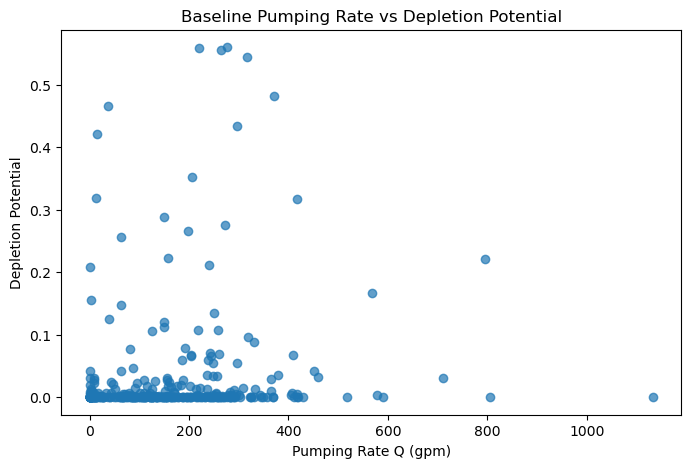

In [29]:
plot_df = depletion_potential_df.dropna(subset=["Q_gpm", "Depletion_Potential"]).copy()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["Q_gpm"], plot_df["Depletion_Potential"], alpha=0.7)
plt.xlabel("Pumping Rate Q (gpm)")
plt.ylabel("Depletion Potential")
plt.title("Baseline Pumping Rate vs Depletion Potential")
plt.show()


## 21. Create a modeling-input uncertainty plan table

This is not a final scientific uncertainty table yet. It is a starting inventory that connects each uncertain quantity to where it appears in the current files.


In [30]:
uncertainty_plan_rows = [
    {
        "uncertain_input": "Transmissivity",
        "symbol": "T",
        "current_location": "project_properties in LPR_Redux.yml",
        "current_value": project_properties.get("T", np.nan),
        "likely_perturbation_first_test": "T × 0.90 and T × 1.10",
        "why_it_matters": "Controls how easily drawdown/depletion signal spreads through the aquifer.",
    },
    {
        "uncertain_input": "Storage",
        "symbol": "S",
        "current_location": "project_properties in LPR_Redux.yml",
        "current_value": project_properties.get("S", np.nan),
        "likely_perturbation_first_test": "S × 0.90 and S × 1.10",
        "why_it_matters": "Controls timing of transient depletion response.",
    },
    {
        "uncertain_input": "Pumping rate",
        "symbol": "Q",
        "current_location": "each well entry in LPR_Redux.yml",
        "current_value": "well-specific",
        "likely_perturbation_first_test": "Q × 0.90 and Q × 1.10 for all wells or selected wells",
        "why_it_matters": "Directly scales pumping stress and stream depletion.",
    },
    {
        "uncertain_input": "Pumping duration",
        "symbol": "days",
        "current_location": "project_properties in LPR_Redux.yml",
        "current_value": project_properties.get("default_pumping_days", np.nan),
        "likely_perturbation_first_test": "test shorter/longer pumping season",
        "why_it_matters": "Controls how long a pumping stress is applied.",
    },
    {
        "uncertain_input": "Depletion time horizon",
        "symbol": "years",
        "current_location": "project_properties in LPR_Redux.yml",
        "current_value": project_properties.get("default_depletion_years", np.nan),
        "likely_perturbation_first_test": "compare 1-year, 5-year, and longer horizons",
        "why_it_matters": "Changes the time window used to evaluate depletion.",
    },
    {
        "uncertain_input": "Stream/well apportionment or stream response structure",
        "symbol": "varies",
        "current_location": "stream-related YAML entries and PyCAP outputs",
        "current_value": "requires detailed review",
        "likely_perturbation_first_test": "inspect before perturbing",
        "why_it_matters": "Controls how depletion is assigned among stream targets.",
    },
    {
        "uncertain_input": "Analytical solution form",
        "symbol": "solution",
        "current_location": "solution/method-related YAML entries or PyCAP defaults",
        "current_value": "requires detailed review",
        "likely_perturbation_first_test": "document current setting before changing",
        "why_it_matters": "Different analytical assumptions may change depletion timing/magnitude.",
    },
]

uncertainty_plan = pd.DataFrame(uncertainty_plan_rows)

uncertainty_plan_path = INVENTORY_DIR / "modeling_input_uncertainty_plan.csv"
uncertainty_plan.to_csv(uncertainty_plan_path, index=False)

print(f"Saved: {uncertainty_plan_path.relative_to(PROJECT_ROOT)}")
uncertainty_plan


Saved: results/pycap_runs/input_inventory/modeling_input_uncertainty_plan.csv


,uncertain_input,symbol,current_location,current_value,likely_perturbation_first_test,why_it_matters
0,Transmissivity,T,project_properties in LPR_Redux.yml,1700.0,T × 0.90 and T × 1.10,Controls how easily drawdown/depletion signal ...
1,Storage,S,project_properties in LPR_Redux.yml,0.12,S × 0.90 and S × 1.10,Controls timing of transient depletion response.
2,Pumping rate,Q,each well entry in LPR_Redux.yml,well-specific,Q × 0.90 and Q × 1.10 for all wells or selecte...,Directly scales pumping stress and stream depl...
3,Pumping duration,days,project_properties in LPR_Redux.yml,90.0,test shorter/longer pumping season,Controls how long a pumping stress is applied.
4,Depletion time horizon,years,project_properties in LPR_Redux.yml,5.0,"compare 1-year, 5-year, and longer horizons",Changes the time window used to evaluate deple...
5,Stream/well apportionment or stream response s...,varies,stream-related YAML entries and PyCAP outputs,requires detailed review,inspect before perturbing,Controls how depletion is assigned among strea...
6,Analytical solution form,solution,solution/method-related YAML entries or PyCAP ...,requires detailed review,document current setting before changing,Different analytical assumptions may change de...


## 22. Save notebook run summary

This summary helps document what the inventory notebook found.


In [31]:
summary_rows = [
    {"item": "project_root", "value": str(PROJECT_ROOT)},
    {"item": "pycap_yaml", "value": str(PYCAP_YAML_PATH.relative_to(PROJECT_ROOT))},
    {"item": "inventory_folder", "value": str(INVENTORY_DIR.relative_to(PROJECT_ROOT))},
    {"item": "number_of_top_level_yaml_keys", "value": len(pycap_config)},
    {"item": "number_of_project_properties", "value": len(project_properties)},
    {"item": "number_of_likely_wells", "value": len(wells_df)},
    {"item": "number_of_flat_yaml_leaf_values", "value": len(flat_yaml)},
    {"item": "number_of_uncertainty_related_yaml_leaf_values", "value": len(uncertainty_key_inventory)},
    {"item": "number_of_stream_related_leaf_values", "value": len(stream_nested)},
    {"item": "number_of_input_files", "value": len(input_file_inventory)},
    {"item": "number_of_excel_sheets", "value": len(excel_sheet_inventory)},
    {"item": "number_of_wells_with_dp", "value": int(dp_values.notna().sum())},
    {"item": "dp_min", "value": float(dp_values.min())},
    {"item": "dp_mean", "value": float(dp_values.mean())},
    {"item": "dp_median", "value": float(dp_values.median())},
    {"item": "dp_max", "value": float(dp_values.max())},
    {"item": "run_timestamp", "value": datetime.now().isoformat(timespec="seconds")},
]

inventory_summary = pd.DataFrame(summary_rows)

inventory_summary_path = INVENTORY_DIR / "pycap_input_inventory_summary.csv"
inventory_summary.to_csv(inventory_summary_path, index=False)

print(f"Saved: {inventory_summary_path.relative_to(PROJECT_ROOT)}")
inventory_summary


Saved: results/pycap_runs/input_inventory/pycap_input_inventory_summary.csv


,item,value
0,project_root,/workspaces/Modeling-Uncertainties
1,pycap_yaml,data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
2,inventory_folder,results/pycap_runs/input_inventory
3,number_of_top_level_yaml_keys,656
4,number_of_project_properties,12
5,number_of_likely_wells,327
6,number_of_flat_yaml_leaf_values,3940
7,number_of_uncertainty_related_yaml_leaf_values,3613
8,number_of_stream_related_leaf_values,1962
9,number_of_input_files,10


## 23. Final interpretation

This notebook gives you the input inventory needed before perturbing parameters.

The main uncertainty-relevant inputs to start with are:

```text
T  → global transmissivity in project_properties
S  → global storage in project_properties
Q  → well-specific pumping rate in each well entry
```

The next notebook should be:

```text
04_pycap_parameter_perturbation.ipynb
```

That notebook should start with simple deterministic perturbations:

```text
T × 0.90
T × 1.10
S × 0.90
S × 1.10
Q × 0.90
Q × 1.10
```

and compare each run to the verified baseline depletion-potential table.
